<h1 class="red-border">Test and analyse of segmentation</h1>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mathisbouvet/MACSima_Advanced-Spatial-Omics-Pipeline/blob/main/notebooks/segmentation/01_segmentation_qc.ipynb)

## Objectif

Ce document présente les différentes étapes de l'analyse de segmentation cellulaire à l’aide de masques ROIs, générés et affichés à partir de fichiers `.zip` et `.tif`.

---

In [2]:
import importlib
import subprocess
import sys

# Dictionnaire
required_packages = {
    "numpy": "numpy",
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "skimage": "scikit-image",
    "read_roi": "read-roi",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "scipy": "scipy"
}

def install_and_import():
    print("🧪 Analyse de l'environnement nlp_env...")
    for module_name, package_name in required_packages.items():
        try:
            importlib.import_module(module_name)
            print(f"✅ {module_name} est déjà prêt.")
        except ImportError:
            print(f"⚠️ {module_name} manque. Installation de {package_name} en cours...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
            print(f"🚀 {package_name} installé avec succès !")

install_and_import()

# 2. Importation des bibliothèques après installation
import numpy as np
import cv2
import pandas as pd  # <-- C'était lui le coupable !
import random
import matplotlib.pyplot as plt
import zipfile
import os
from skimage.draw import polygon, polygon_perimeter
from read_roi import read_roi_file
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest
import seaborn as sns

print("✨ Tous les modules sont importés et prêts à l'emploi !")

🧪 Analyse de l'environnement nlp_env...
✅ numpy est déjà prêt.
✅ cv2 est déjà prêt.
✅ matplotlib est déjà prêt.
✅ skimage est déjà prêt.
✅ read_roi est déjà prêt.
✅ pandas est déjà prêt.
✅ sklearn est déjà prêt.
✅ scipy est déjà prêt.
✅ seaborn est déjà prêt.
✨ Tous les modules sont importés et prêts à l'emploi !


## 1 Création des masques à partir des ROIs
### 1.a Création des ROIs via Fiji et importation dans l'environnement Python

In [3]:
image = cv2.imread("C2.tif")
if image is None:
    raise FileNotFoundError("Image TIFF not found or unreadable")

extract_folder = "roi_dezip"

with zipfile.ZipFile("RoiSetC2.zip", "r") as zip_ref:
    zip_ref.extractall(extract_folder)

roi_files = [f for f in os.listdir(extract_folder) if f.endswith(".roi")]
roi_data = {}
for roi_file in roi_files:
    roi_path = os.path.join(extract_folder, roi_file)
    roi_data.update(read_roi_file(roi_path))

print(f"Nombre de ROIs chargés : {len(roi_data)}")

Nombre de ROIs chargés : 4667


Attention à bien vérifier le nombre de ROIs importé. Il doit correspondre aux nombres de cellule segmenté manuellement

### 1.b Génération des masques 


In [4]:
#ROIs colorées + fond noir
masked_image = np.zeros_like(image)
def generate_random_color():
    return (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
for roi_name, roi in roi_data.items():
    x = np.array(roi["x"])
    y = np.array(roi["y"])
    rr, cc = polygon(y, x, shape=image.shape[:2])
    color = generate_random_color()
    masked_image[rr, cc] = color
cv2.imwrite("mask_1.tif", masked_image)

#ROIs colorées (2) + fond noir
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
masked_image = np.zeros_like(image)
roi_color_idx = 0 
for roi_name, roi in roi_data.items():
    x = np.array(roi["x"])
    y = np.array(roi["y"])
    rr, cc = polygon(y, x, shape=image.shape[:2])
    color = colors[roi_color_idx]
    masked_image[rr, cc] = color
    roi_color_idx = (roi_color_idx + 1) % len(colors)
cv2.imwrite("mask_2.tif", masked_image)

#ROIs en niveau de gris
gray_mask = np.zeros(image.shape[:2], dtype=np.uint8)
for roi_name, roi in roi_data.items():
    x = np.array(roi["x"])
    y = np.array(roi["y"])
    rr, cc = polygon(y, x, shape=image.shape[:2])
    gray_mask[rr, cc] = np.clip(gray_mask[rr, cc] + 50, 0, 255)
cv2.imwrite("mask_3.tif", gray_mask)

#ROIs en niveau de gris + contours
gray_mask = np.zeros(image.shape[:2], dtype=np.uint8)
for roi_name, roi in roi_data.items():
    x = np.array(roi["x"])
    y = np.array(roi["y"])
    rr, cc = polygon(y, x, shape=image.shape[:2])
    gray_mask[rr, cc] = np.clip(gray_mask[rr, cc] + 50, 0, 255)
    rr_perim, cc_perim = polygon_perimeter(y, x, shape=image.shape[:2])
    gray_mask[rr_perim, cc_perim] = 0
cv2.imwrite("mask_4.tif", gray_mask)

True

Une fois ce code exécuté, plusieurs masques seront disponibles à importer dans MACSiQ View. Le mieux est de placer les masques directement dans le dossier contenant les fichiers `.tiff` issus de l'acquisition. Pour les importer, il suffit de les glisser-déposer dans MACSiQ View. Les masques sont ainsi interprétés par MACSiQView comme une acquisition immunofluorescente. 

### 1.c Segmentation MACSiQView sur les masques générés par Python et comparaison entre elle

Le logiciel MACSiQView propose différents algorithmes de segmentation. L’objectif de cette étude est d'évaluer les quatre modalités disponibles (Import mask, Import label, Single Cell et Tissue) afin d'identifier celle offrant la segmentation la plus fidèle aux structures biologiques. Une fois la segmentation validée, l’onglet "Feature Table" permet de sélectionner les descripteurs à intégrer dans l’analyse. Cette étape assure l'exportation exclusive des données morphologiques cellulaires, indépendamment des intensités de fluorescence. Le fichier ainsi généré, au format .csv, est ensuite importé dans un environnement Python. Parmi l’ensemble des variables extraites, les paramètres suivants ont été retenus : Area, Perimeter, Centroid X et Y, Feret et Mean Intensity .

## 2 Comparaison des différentes segmentations 

Tout d'abord, on importe les segmentations automatiques df_auto et la segmentation manuel df_manual. On garde seulement les points de comparaison suivant : Area, Perimeter, Centroid X et Y, Feret et Mean intensity.

In [5]:
df_manual = pd.read_csv("Segmentation_manuelle.csv")

df_autos = [
    pd.read_csv("Mask_3_Single_Cell.csv"),
    pd.read_csv("Mask_3_Tissue.csv"),
    pd.read_csv("Mask_4_Import_mask.csv"),
    pd.read_csv("Mask_4_Single_Cell.csv"),
    pd.read_csv("Mask_4_Tissue.csv")
]

df_manual = df_manual.rename(columns={
    'Area': 'area',
    'Perim.': 'perimeter',
    'XM': 'centroid_x',
    'YM': 'centroid_y',
    'Feret': 'feret',
    'Mean': 'mean_intensity'
})

columns_to_keep = ['area', 'perimeter', 'centroid_x', 'centroid_y', 'feret', 'mean_intensity']
df_manual = df_manual[columns_to_keep]

print("Avant normalisation :")
print(df_manual.head(), "\n")

def rename_auto(df):
    return df.rename(columns={
        'Nucleus Size': 'area',
        'Nucleus Contour Length': 'perimeter',
        'Nuc X': 'centroid_x',
        'Nuc Y': 'centroid_y',
        'Nucleus Feret Diameter Max': 'feret',
        'Nucleus DNA Mean': 'mean_intensity'
    })[columns_to_keep]

df_autos = [rename_auto(df) for df in df_autos]

# fit sur df_manual uniquement, transform sur tous
scaler = MinMaxScaler()
df_manual[columns_to_keep] = scaler.fit_transform(df_manual[columns_to_keep])
for df_auto in df_autos:
    df_auto[columns_to_keep] = scaler.transform(df_auto[columns_to_keep])

print("Après normalisation :")
print(df_manual.head())
print(df_autos[0].head())

# Construction de df_comparison
df_comparison = df_manual[columns_to_keep].copy()
for i, df_auto in enumerate(df_autos, start=1):
    for col in columns_to_keep:
        df_comparison[f'{col}_auto{i}'] = df_auto[col]

Avant normalisation :
     area  perimeter  centroid_x  centroid_y  feret  mean_intensity
0  46.847     26.938     541.304     684.308  9.902       28839.072
1  53.696     28.015     555.683     680.998  9.666       26216.349
2  49.448     28.905     568.930     678.510  9.738       23411.863
3  53.696     27.486     565.926     672.050  9.164       37120.984
4  48.957     27.381     548.771     679.931  9.913       27413.476 

Après normalisation :
       area  perimeter  centroid_x  centroid_y     feret  mean_intensity
0  0.280201   0.392570    0.465225    0.929694  0.329062        0.429441
1  0.323774   0.414186    0.482739    0.924882  0.317429        0.378035
2  0.296748   0.432049    0.498874    0.921265  0.320978        0.323066
3  0.323774   0.403569    0.495215    0.911873  0.292685        0.591770
4  0.293625   0.401461    0.474320    0.923330  0.329604        0.401499
         area  perimeter  centroid_x  centroid_y      feret  mean_intensity
0  312.355328  22.001938    4.19

In [6]:
legend_mapping = {
    f'Auto{i+1}': name for i, name in enumerate([
        'Mask 3 - Single Cell',
        'Mask 3 - Tissue',
        'Mask 4 - Import Mask',
        'Mask 4 - Single Cell',
        'Mask 4 - Tissue'
    ])
}

distances = {
    column: [ks_2samp(df_manual[column], df_auto[column])[0] for df_auto in df_autos]
    for column in columns_to_keep
}

distances_df = pd.DataFrame(distances, index=list(legend_mapping.keys()))
distances_df['Mean Distance'] = distances_df.mean(axis=1)

print("Average Kolmogorov-Smirnov distances for each segmentation :")
print(distances_df['Mean Distance'])

closest_auto = distances_df['Mean Distance'].idxmin()
print(f"\nThe segmentation closest to df_manual is : {legend_mapping[closest_auto]}")

Average Kolmogorov-Smirnov distances for each segmentation :
Auto1    0.958053
Auto2    0.999648
Auto3    0.997134
Auto4    0.879743
Auto5    0.999646
Name: Mean Distance, dtype: float64

The segmentation closest to df_manual is : Mask 4 - Single Cell


Avec ça, on est capable d'identifier la segmentation la plus proche

In [7]:
closest_auto = distances_df['Mean Distance'].idxmin()
print(f"\nLa df_auto la plus proche de df_manual est : {legend_mapping[closest_auto]}")


La df_auto la plus proche de df_manual est : Mask 4 - Single Cell


On réalise également les barplot des distances moyennes

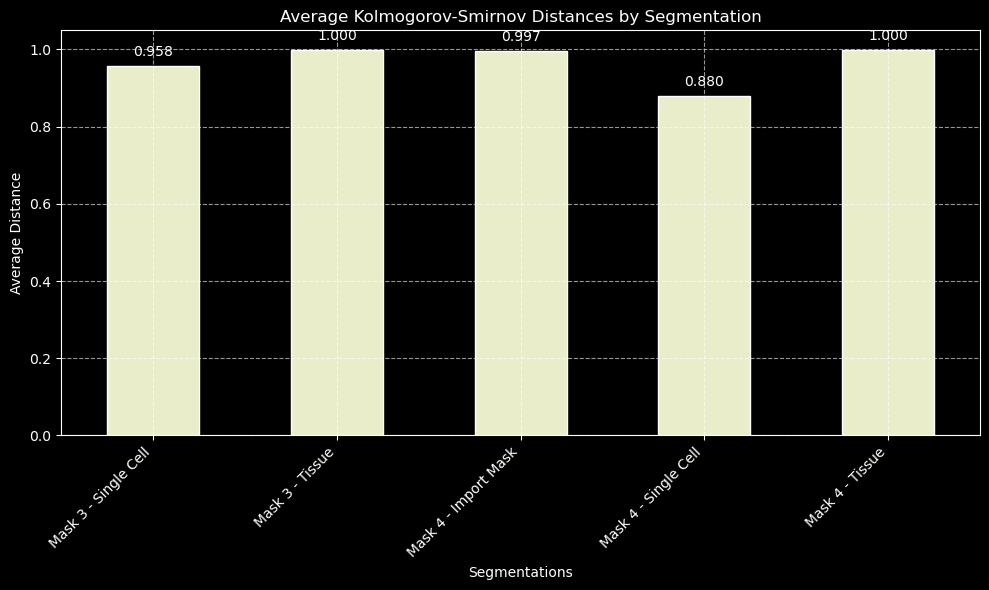

In [8]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

ax = distances_df['Mean Distance'].plot(kind='bar', color='#E9EDC9', edgecolor='white')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', color='white')

plt.title('Average Kolmogorov-Smirnov Distances by Segmentation', color='white')
plt.ylabel('Average Distance', color='white')
plt.xlabel('Segmentations', color='white')
plt.xticks(ticks=range(len(legend_mapping)), labels=[legend_mapping[item] for item in distances_df.index], rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.grid(True, linestyle='--', alpha=0.6, color='white')
ax.set_facecolor('black')
ax.figure.set_facecolor('black')
plt.tight_layout()
plt.savefig('figures/ks_average_distances.png', format='png', facecolor='black')
plt.show()

On visualise également les courbes de densité (KDE) pour comparer la forme des distributions

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

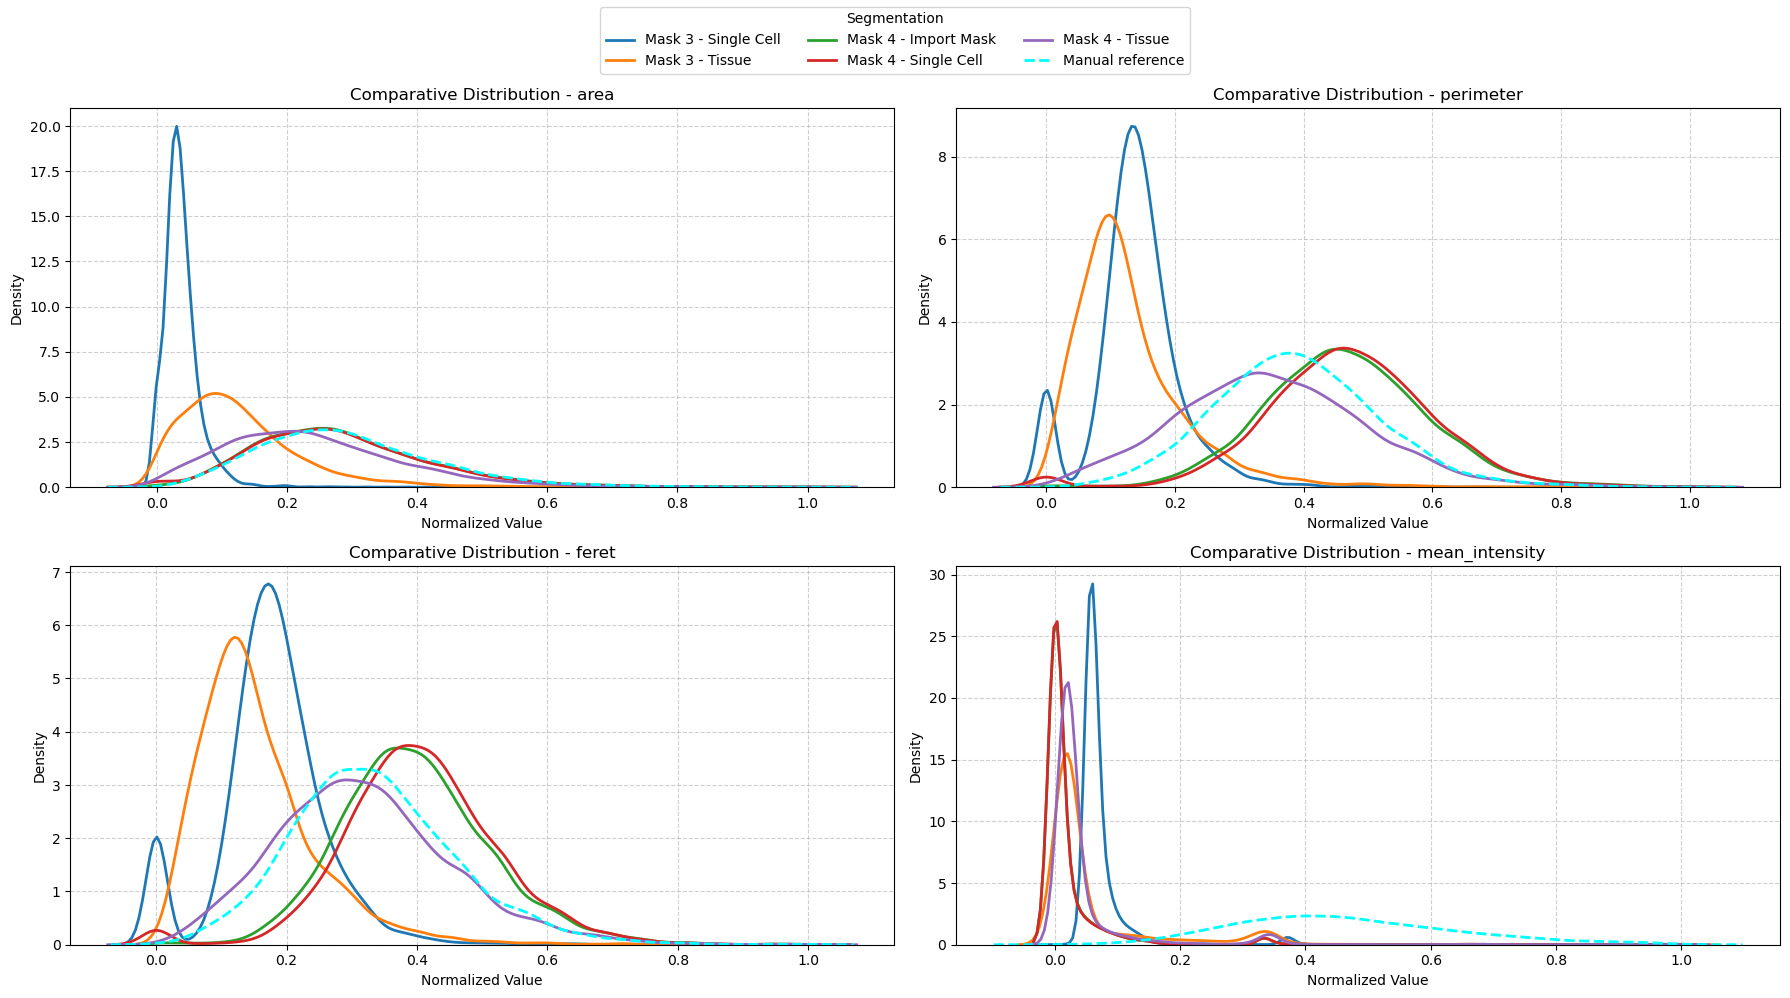

In [9]:
# Normalisation indépendante pour le KDE
df_manual_kde = pd.DataFrame(
    MinMaxScaler().fit_transform(df_manual[columns_to_keep]),
    columns=columns_to_keep
)
df_autos_kde = [
    pd.DataFrame(MinMaxScaler().fit_transform(df[columns_to_keep]), columns=columns_to_keep)
    for df in df_autos
]

# Construction de df_comparison_kde
df_comparison_kde = df_manual_kde[columns_to_keep].copy()
for i, df_auto in enumerate(df_autos_kde, start=1):
    for col in columns_to_keep:
        df_comparison_kde[f'{col}_auto{i}'] = df_auto[col]

# KDE plot
plt.style.use('default')
params = ['area', 'perimeter', 'feret', 'mean_intensity']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for idx, param in enumerate(params):
    ax = axes[idx]
    ax.set_facecolor('white')

    for i in range(1, 6):
        key = f'Auto{i}'
        colname = f'{param}_auto{i}'
        if colname in df_comparison_kde.columns:
            sns.kdeplot(df_comparison_kde[colname], label=legend_mapping[key], linewidth=2, ax=ax)
        else:
            raise KeyError(f"Missing column in df_comparison_kde : {colname}")

    if param in df_comparison_kde.columns:
        sns.kdeplot(df_comparison_kde[param], label='Manual reference', color='cyan', linestyle='--', linewidth=2, ax=ax)
    else:
        raise KeyError(f"Missing manual column : {param}")

    ax.set_title(f'Comparative Distribution - {param}')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Density')
    ax.grid(True, linestyle='--', alpha=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Segmentation', loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig('figures/kde_comparative_distributions.png', format='png', facecolor='white')
plt.show()


## 3 Bonne segmentation ?

Cette étude a pour objet l’évaluation comparative d’une segmentation automatisée réalisée sous MACSiQ View par rapport à une méthodologie de référence établie à partir de masques de régions d'intérêt (ROI) générés manuellement. Les données issues de la segmentation manuelle, déjà compilées, constituent le jeu de données de référence df_ref. La présente analyse vise à appliquer une procédure identique à une image DAPI issue d'une immunofluorescence MACSima, dont les résultats sont consignés dans le jeu de données df_test. En assurant une stricte uniformité des paramètres d'exportation, cette approche permet de quantifier la précision de la segmentation automatisée, d'en valider la pertinence scientifique et de formuler des hypothèses d'optimisation pour les protocoles de traitement d'image ultérieurs.

Les étapes de vérification intégrées au script, bien qu'elles en augmentent la complexité, permettent de s'assurer que les colonnes sont conformes aux paramètres préalablement sélectionnés.

Une fois les colonnes triés et les données normalisés (c'est obligatoire). On utilise Isolation Forest qui sera entraîné uniquement sur la référence X_ref_scaled (car nous avons segmenté manuellement qu'une seule image). On suppose une contamination de 10%

Pour vérifier la sensibilité au paramètre de contamination, on fait tourner le modèle d'isolation sur différente valeur de contamination. Pour chaque valeur, on regarde quel pourcentage de cellules test est classé "OK"

On importe les fichiers de référence `df_ref` et de test `df_test`. On vérifie que les 14 features morphologiques sont bien présentes dans les deux fichiers. Les données sont ensuite normalisées via `StandardScaler` — `fit` uniquement sur `X_ref`, `transform` sur `X_test` pour garantir que l'échelle de référence est celle de la segmentation manuelle.

In [10]:
import warnings
warnings.filterwarnings("ignore")

df_ref = pd.read_csv("Segmentation(1).csv")
df_test = pd.read_csv("Segmentation_EH3524.csv")

df_ref.columns = df_ref.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

features_to_use = [
    "Cell Bbox X Size", "Cell Bbox Y Size", "Cell Shape Circle Like", "Cell Shape Ellipse Like",
    "Cell Shape Elongation", "Cell Shape Square Like", "Cell Shape Triangle Like",
    "Cell Size", "Nucleus Size", "Nucleus Roundness", "Nucleus Convexity", "Cell Convexity",
    "Quality Cell In-Focus", "Quality Nuclear Segmentation"
]

missing = [col for col in features_to_use if col not in df_ref.columns or col not in df_test.columns]
if missing:
    raise ValueError(f"Missing columns in files : {missing}")

X_ref = df_ref[features_to_use].dropna()
X_test = df_test[features_to_use].dropna()
df_test_clean = df_test.loc[X_test.index].copy()

scaler = StandardScaler()
X_ref_scaled = scaler.fit_transform(X_ref)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Reference : {len(X_ref)} cells · Test : {len(X_test)} cells")

✅ Reference : 4641 cells · Test : 8091 cells


Avant de fixer le paramètre de contamination, on analyse la sensibilité du modèle en faisant tourner l'Isolation Forest sur différentes valeurs (0.01 → 0.20). Pour chaque valeur, on regarde quel pourcentage de cellules test est classé "OK". Cela permet de choisir une valeur de contamination biologiquement cohérente.

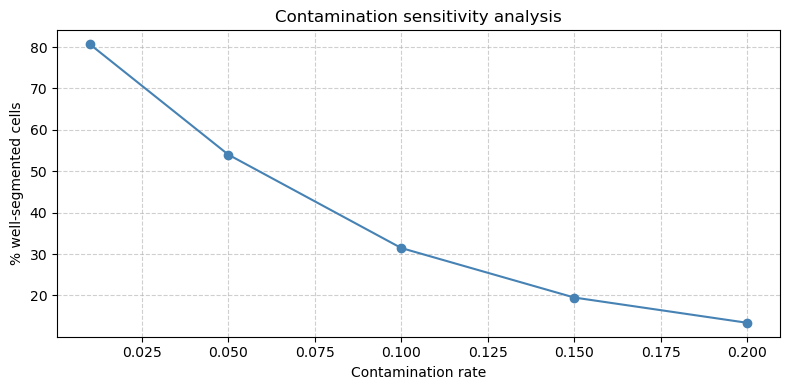

Contamination · % OK
  0.01 → 80.7%
  0.05 → 54.0%
  0.10 → 31.5%
  0.15 → 19.5%
  0.20 → 13.4%


In [11]:
# Sensitivity analysis - choosing best contamination
contamination_values = [0.01, 0.05, 0.10, 0.15, 0.20]
ok_percentages = []

for c in contamination_values:
    model = IsolationForest(contamination=c, random_state=42)
    model.fit(X_ref_scaled)
    preds = model.predict(X_test_scaled)
    ok_percent = (preds == 1).sum() / len(preds) * 100
    ok_percentages.append(ok_percent)

plt.figure(figsize=(8, 4))
plt.plot(contamination_values, ok_percentages, marker='o', color='steelblue')
plt.xlabel("Contamination rate")
plt.ylabel("% well-segmented cells")
plt.title("Contamination sensitivity analysis")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figures/contamination_sensitivity.png', format='png')
plt.show()

print("Contamination · % OK")
for c, pct in zip(contamination_values, ok_percentages):
    print(f"  {c:.2f} → {pct:.1f}%")

Une fois la valeur de contamination choisie, on entraîne le modèle final uniquement sur `X_ref_scaled`. En plus du label `-1/+1`, on récupère le score continu via `decision_function` — plus le score est négatif, plus la cellule est anormale. Les résultats sont exportés dans `segmentation_test_annotated.csv`.


✅ Result with contamination=0.10 :
2545 / 8091 cells considered well-segmented (31.45%)


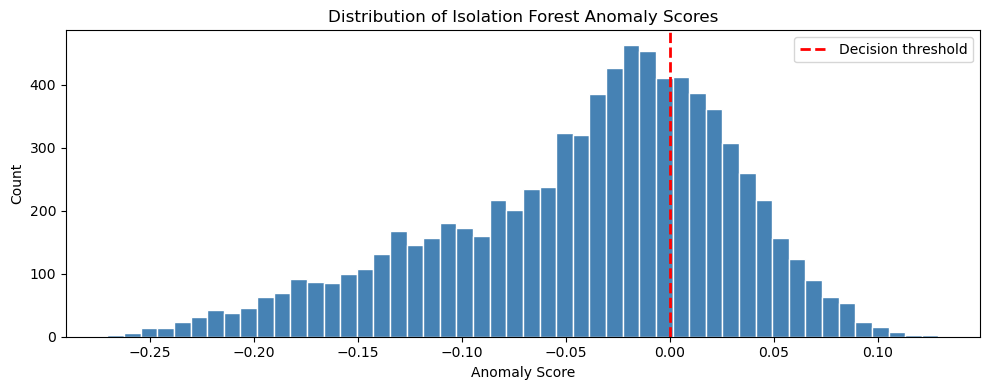

💾 Result saved in : segmentation_test_annotated.csv


In [12]:
# Final model with chosen contamination
best_contamination = 0.10

model = IsolationForest(contamination=best_contamination, random_state=42)
model.fit(X_ref_scaled)
preds = model.predict(X_test_scaled)
scores = model.decision_function(X_test_scaled)

df_test_clean["Segmentation_OK"] = preds
df_test_clean["Anomaly_Score"] = scores

nb_total = len(preds)
nb_valides = (preds == 1).sum()
pourcentage = nb_valides / nb_total * 100

print(f"\n✅ Result with contamination={best_contamination:.2f} :")
print(f"{nb_valides} / {nb_total} cells considered well-segmented ({pourcentage:.2f}%)")

# Anomaly score distribution
plt.figure(figsize=(10, 4))
plt.hist(scores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision threshold')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.title('Distribution of Isolation Forest Anomaly Scores')
plt.legend()
plt.tight_layout()
plt.savefig('figures/anomaly_scores_distribution.png', format='png')
plt.show()

df_test_clean.to_csv("segmentation_test_annotated.csv", index=False)
print("💾 Result saved in : segmentation_test_annotated.csv")

Si le modèle d'Isolation compare des paramètres et en définit certaine comme négatif à une certaien segmentation, alors, il est possible d'avoir des indicateurs d'amélioration dans les paramètres de segmentation. On construit une dictionnaire qui relie une variable mesurée au paramètre MACSiQView et ainsi on peut définir ce qu'il faut faire (diminution ou augmentation du paramètre). Le test de Mann-Whitney U est utiliser pour comparer la distribution OK vs KO. Si la différence est statistiquement différentes (p < 0,01) on regarde si la valeur moyenne chez les KO est plus petite ou plus grande que chez les OK, on en déduis alors une direction (KO < OK ou KO > OK), on le traduis en suggestion MACSiQView et on calcules un pourcentage de différence approximatif entre OK et KO.

In [20]:

param_map = {
    "Nucleus Size": ("Diamètre min / max", "↑ diamètre min", "↑ diamètre max"),
    "Cell Size": ("Diamètre min / max", "↑ diamètre min", "↑ diamètre max"),
    "Cell Bbox X Size": ("Diamètre max", "↑ diamètre min", "↑ diamètre max"),
    "Cell Bbox Y Size": ("Diamètre max", "↑ diamètre min", "↑ diamètre max"),
    "Nucleus Roundness": ("Séparation / Smoothing", "↑ séparation", "↓ séparation ou ↓ smoothing"),
    "Nucleus Convexity": ("Smoothing filter sigma", "↑ sigma", "↓ sigma"),
    "Cell Convexity": ("Smoothing filter sigma", "↑ sigma", "↓ sigma"),
    "Cell Shape Ellipse Like": ("Contours / Smoothing", "↑ smoothing", "↓ smoothing"),
    "Cell Shape Circle Like": ("Contours / Smoothing", "↑ smoothing", "↓ smoothing"),
    "Cell Shape Elongation": ("Contours / Séparation", "↓ séparation", "↑ séparation"),
    "Cell Shape Square Like": ("Contours", "-", "-"),
    "Cell Shape Triangle Like": ("Contours", "-", "-"),
    "Quality Cell In-Focus": ("Qualité image (acquisition)", "-", "-"),
    "Quality Nuclear Segmentation": ("Sensibilité / Smoothing", "↑ sensibilité", "↓ sensibilité"),
}
df = df_test_clean.copy()
df = df.dropna(subset=features_to_use + ['Segmentation_OK'])
df['Segmentation_Label'] = df['Segmentation_OK'].map({1: 'OK', -1: 'KO'})
summary = []
for feature in features_to_use:
    ok_vals = df[df['Segmentation_Label'] == 'OK'][feature]
    ko_vals = df[df['Segmentation_Label'] == 'KO'][feature]

    if len(ok_vals) < 10 or len(ko_vals) < 10:
        continue

    stat, p = mannwhitneyu(ok_vals, ko_vals, alternative='two-sided')
    mean_ok = ok_vals.mean()
    mean_ko = ko_vals.mean()

    direction = "-"
    suggestion = "-"
    percent_change = "-"
    param = param_map.get(feature, ("-", "-", "-"))[0]

    if p < 0.01:
        if mean_ko < mean_ok:
            direction = "KO < OK"
            suggestion = param_map[feature][1]
            percent_change = f"+{round((1 - mean_ko / mean_ok) * 100, 1)} %"
        elif mean_ko > mean_ok:
            direction = "KO > OK"
            suggestion = param_map[feature][2]
            percent_change = f"+{round((mean_ko / mean_ok - 1) * 100, 1)} %"

    summary.append({
        "Variable": feature,
        "Moyenne OK": round(mean_ok, 2),
        "Moyenne KO": round(mean_ko, 2),
        "Différence": direction,
        "Paramètre MACSiQ lié": param,
        "Suggestion d’ajustement": suggestion,
        "% de changement indicatif": percent_change,
        "p-value": round(p, 4)
    })
summary_df = pd.DataFrame(summary).sort_values("p-value")

# Affichage console
print("\n🧠 Résumé des paramètres MACSiQ à ajuster :\n")
print(summary_df.to_string(index=False))

# Export CSV
summary_df.to_csv("macsiq_param_suggestions.csv", index=False)
print("\n💾 Résumé exporté dans : macsiq_param_suggestions.csv")


🧠 Résumé des paramètres MACSiQ à ajuster :

                    Variable  Moyenne OK  Moyenne KO Différence        Paramètre MACSiQ lié Suggestion d’ajustement % de changement indicatif  p-value
            Cell Bbox X Size       52.18       62.63    KO > OK                Diamètre max          ↑ diamètre max                   +20.0 %      0.0
            Cell Bbox Y Size       50.12       59.38    KO > OK                Diamètre max          ↑ diamètre max                   +18.5 %      0.0
      Cell Shape Circle Like        0.62        0.53    KO < OK        Contours / Smoothing             ↑ smoothing                   +15.0 %      0.0
     Cell Shape Ellipse Like        0.85        0.79    KO < OK        Contours / Smoothing             ↑ smoothing                    +7.3 %      0.0
       Cell Shape Elongation        3.95        4.21    KO > OK       Contours / Séparation            ↑ séparation                    +6.6 %      0.0
      Cell Shape Square Like        0.67        0